In [2]:
import matplotlib

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

import os

import matplotlib.pyplot as plt
import pandas as pd
import ptitprince as pt
import seaborn as sns

In [11]:
plot_info = []

for root, sub_dir, files in os.walk("../utils/gen_within_100"):
    for file in files:
        if file.endswith(".csv"):
            try:
                src_file = os.path.join(root, file)
                dim = int(file[3])
                obj = int(file[9])
                tree = file[16:].strip(".csv")
                df = pd.read_csv(src_file, index_col=0).fillna(0)
                print(src_file)
                df["dimension"] = dim
                df["n_objectives"] = obj
                df["tree"] = tree
                print(df)
                plot_info.append(df)
            except FileNotFoundError as e:
                print(f"Error processing file {file}: {e}")

../utils/gen_within_100/dim4_objs3_tree_breadth_gen_80.csv
    solver  exp_index  root  node_1  node_2  node_3  node_4  dimension  \
0     IBEA      64262    86       0      14       0       0          4   
1     IBEA      64263    89       0       0       0      11          4   
2     IBEA      64264    74      26       0       0       0          4   
3     IBEA      64265    73      27       0       0       0          4   
4     IBEA      64266    70       0      30       0       0          4   
..     ...        ...   ...     ...     ...     ...     ...        ...   
295   IBEA      64557    73       0       0      27       0          4   
296   IBEA      64558    78       0       0       0      22          4   
297   IBEA      64559    78      18       0       0       4          4   
298   IBEA      64560    74       0       0      26       0          4   
299   IBEA      64561    79       0      21       0       0          4   

     n_objectives            tree  
0               

In [12]:
new_df = pd.concat(plot_info, ignore_index=True)

In [25]:
new_df

,solver,exp_index,root,node_1,node_2,node_3,node_4,dimension,n_objectives,tree
0,IBEA,64262,86,0,14,0,0,4,3,breadth_gen_80
1,IBEA,64263,89,0,0,0,11,4,3,breadth_gen_80
2,IBEA,64264,74,26,0,0,0,4,3,breadth_gen_80
3,IBEA,64265,73,27,0,0,0,4,3,breadth_gen_80
4,IBEA,64266,70,0,30,0,0,4,3,breadth_gen_80
...,...,...,...,...,...,...,...,...,...,...
108067,IBEA,34838,82,2,9,7,0,2,4,breadth_gen_60
108068,IBEA,34839,83,0,2,14,1,2,4,breadth_gen_60
108069,IBEA,34840,70,0,2,0,28,2,4,breadth_gen_60
108070,IBEA,34841,92,0,8,0,0,2,4,breadth_gen_60


In [45]:
solver = "IBEA"
dim_n_obj_combs = [(4, 3), (3, 4), (2, 5)]
tree = "breadth_gen_10"
shift_dim = False
if shift_dim:
    filtered_dfs = []
    for dim_n_obj_comb in dim_n_obj_combs:
        dimension = dim_n_obj_comb[0]
        n_objectives = dim_n_obj_comb[1]
        filtered_dfs.append(
            new_df[
                (new_df["solver"] == solver)
                & (new_df["dimension"] == dimension)
                & (new_df["tree"] == tree)
                & (new_df["n_objectives"] == n_objectives)
            ]
        )
    filtered_df = pd.concat(filtered_dfs)
else:
    dimension = 2
    n_objectives = [2, 3, 4, 5]
    filtered_df = new_df[(new_df["solver"] == solver) & (new_df["dimension"] == dimension) & (new_df["tree"] == tree)]

In [48]:
filtered_df
print(len(filtered_df))

1501


/Users/umi/miniconda3/envs/benchmark-visualizer/lib/python3.10/site-packages/ptitprince/PtitPrince.py:154: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for group_name, group_df in self.plot_data.groupby(grouping_vars):
/Users/umi/miniconda3/envs/benchmark-visualizer/lib/python3.10/site-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/Users/umi/miniconda3/envs/benchmark-visualizer/lib/python3.10/site-packages/ptitprince/PtitPrince.py:1143: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `

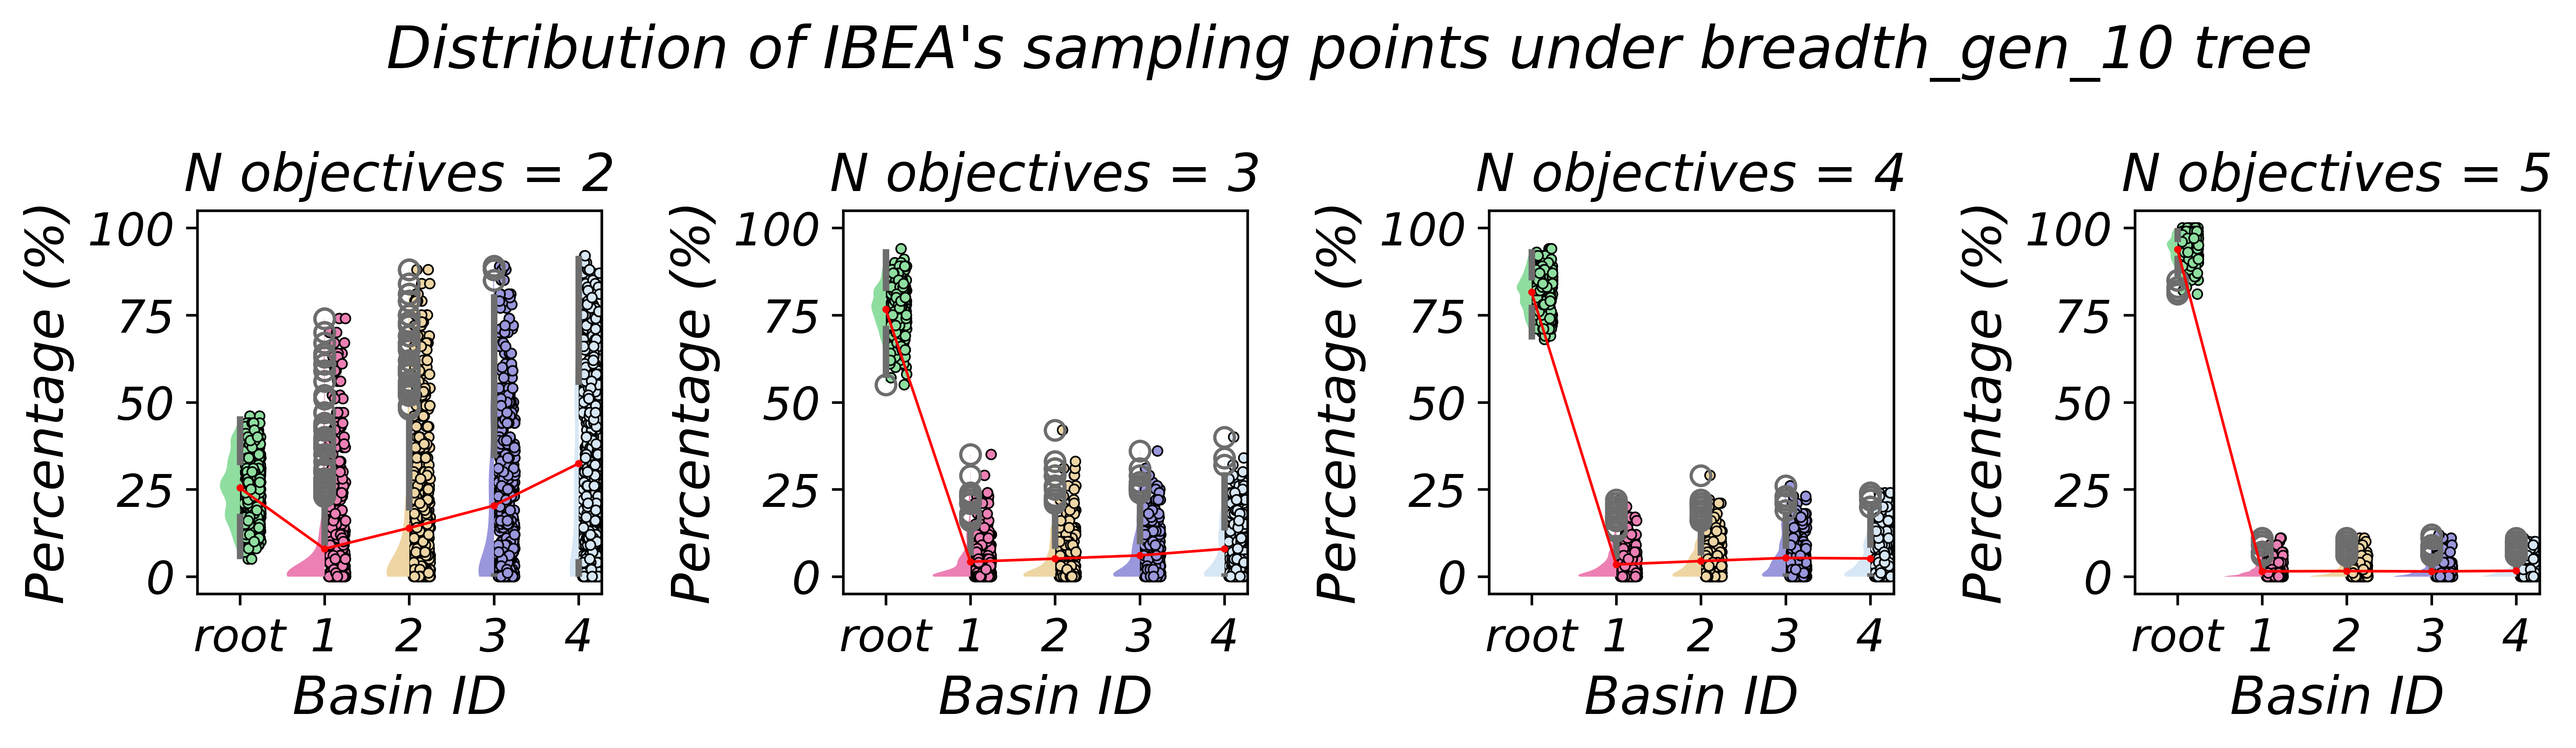

In [ ]:
if solver == "MOEAD":
    solver = "MOEA/D"
if solver == "NSGAII":
    solver = "NSGA-II"

fig, axs = plt.subplots(1, 4, figsize=(11, 3), dpi=600)
fig.suptitle(f"Distribution of {solver}'s sampling points under {tree} tree", fontsize=18)
fig.tight_layout(pad=2, w_pad=4, h_pad=5)
width = 0.6
colors = ["#8fdea0", "#ec80b4", "#eed5a4", "#9a97dc", "#d7e7f5"]
palette = sns.color_palette(colors)

for n_objective, sub_df in filtered_df.groupby("n_objectives"):
    sub_results = []
    for sub_index, row in sub_df.iterrows():
        sub_results.append({"node_name": "root", "percentage": row["root"]})
        sub_results.append({"node_name": "1", "percentage": row["node_1"]})
        sub_results.append({"node_name": "2", "percentage": row["node_2"]})
        sub_results.append({"node_name": "3", "percentage": row["node_3"]})
        sub_results.append({"node_name": "4", "percentage": row["node_4"]})
    sub_results = pd.DataFrame(sub_results)
    plt.subplot(1, 4, n_objective - 1)
    plt.title(f"N objectives = {n_objective}", fontsize=16)
    # pt.RainCloud(x="day", y="total_bill", data=tips, orient="v")
    # axs[plot_row,plot_col].set_xlabel("Basin name")
    # axs[plot_row,plot_col].set_ylabel("Percentage of solver instances")
    # axs[plot_row,plot_col].set_ylim([-5, 105])

    plt.ylim([-5, 105])
    # plt.grid(visible=False)
    pt.RainCloud(
        data=sub_results,
        x="node_name",
        y="percentage",
        orient="v",
        width_viol=0.9,
        linewidth=0.1,
        point_size=3,
        rain_edgecolor="black",
        rain_linewidth=0.5,
        rain_alpha=1,
        move=0.15,
        width_box=0,
        box_linewidth=0,
        offset=-0.0,
        pointplot=True,
        point_scale=0.3,
        palette=palette,
    )
    plt.xlabel("Basin ID", fontsize=16)
    plt.ylabel("Percentage (%)", fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
plt.savefig(
    f"{solver}_{tree}{'_shifted' if shift_dim else ''}.pdf",
    format="pdf",
    bbox_inches="tight",
)
plt.savefig(f"{solver}_{tree}{'_shifted' if shift_dim else ''}.png")

In [22]:
dim_n_obj_combs = []
for i in range(2, 6):
    for j in range(2, 6):
        dim_n_obj_combs.append((i, j))
print(dim_n_obj_combs)

[(2, 2), (2, 3), (2, 4), (2, 5), (3, 2), (3, 3), (3, 4), (3, 5), (4, 2), (4, 3), (4, 4), (4, 5), (5, 2), (5, 3), (5, 4), (5, 5)]


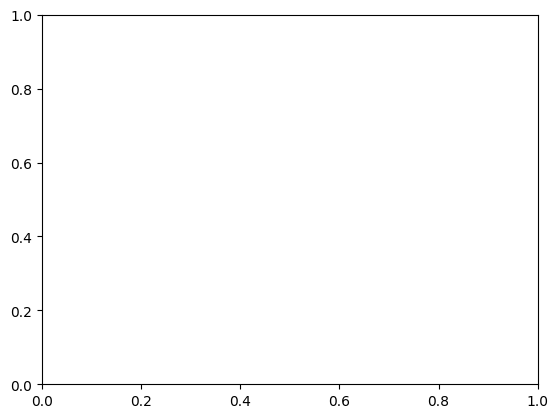

In [23]:
# Mass plot
for solver in ["GDE3", "NSGAII", "IBEA", "MOEAD"]:
    for tree in ["breadth", "depth", "diverse_tree"]:
        for dimension in [2, 3, 4, 5]:
            shift_dim = False
            if shift_dim:
                filtered_dfs = []
                for dim_n_obj_comb in dim_n_obj_combs:
                    dimension = dim_n_obj_comb[0]
                    n_objectives = dim_n_obj_comb[1]
                    filtered_dfs.append(
                        new_df[
                            (new_df["solver"] == solver)
                            & (new_df["dimension"] == dimension)
                            & (new_df["tree"] == tree)
                            & (new_df["n_objectives"] == n_objectives)
                        ]
                    )
                filtered_df = pd.concat(filtered_dfs)
            else:
                n_objectives = [2, 3, 4, 5]
                filtered_df = new_df[
                    (new_df["solver"] == solver) & (new_df["dimension"] == dimension) & (new_df["tree"] == tree)
                ]

            if solver == "MOEAD":
                solver_name = "MOEA/D"
            elif solver == "NSGAII":
                solver_name = "NSGA-II"
            else:
                solver_name = solver

            fig, axs = plt.subplots(1, 4, figsize=(12, 3), dpi=600)
            fig.suptitle(
                f"Distribution of {solver_name}'s sampling points under {tree} tree $\operatorname{{dim}}X={dimension}$",
                fontsize=18,
            )
            fig.tight_layout(pad=2, w_pad=4, h_pad=5)
            width = 0.6
            colors = ["#8fdea0", "#ec80b4", "#eed5a4", "#9a97dc", "#d7e7f5"]
            palette = sns.color_palette(colors)

            for n_objective, sub_df in filtered_df.groupby("n_objectives"):
                sub_results = []
                for sub_index, row in sub_df.iterrows():
                    sub_results.append({"node_name": "root", "percentage": row["root"]})
                    sub_results.append({"node_name": "1", "percentage": row["node_1"]})
                    sub_results.append({"node_name": "2", "percentage": row["node_2"]})
                    sub_results.append({"node_name": "3", "percentage": row["node_3"]})
                    sub_results.append({"node_name": "4", "percentage": row["node_4"]})
                sub_results = pd.DataFrame(sub_results)
                plt.subplot(1, 4, n_objective - 1)
                plt.title(f"N objectives = {n_objective}", fontsize=16)
                # pt.RainCloud(x="day", y="total_bill", data=tips, orient="v")
                # axs[plot_row,plot_col].set_xlabel("Basin name")
                # axs[plot_row,plot_col].set_ylabel("Percentage of solver instances")
                # axs[plot_row,plot_col].set_ylim([-5, 105])

                plt.ylim([-5, 105])
                # plt.grid(visible=False)
                pt.RainCloud(
                    data=sub_results,
                    x="node_name",
                    y="percentage",
                    orient="v",
                    width_viol=0.9,
                    linewidth=0.1,
                    point_size=3,
                    rain_edgecolor="black",
                    rain_linewidth=0.5,
                    rain_alpha=1,
                    move=0.15,
                    width_box=0,
                    box_linewidth=0,
                    offset=-0.0,
                    pointplot=True,
                    point_linestyles="",
                    point_scale=0.3,
                    palette=palette,
                )
                plt.xlabel("Basin ID", fontsize=16)
                plt.ylabel("Percentage (%)", fontsize=16)
                plt.xticks(fontsize=14)
                plt.yticks(fontsize=14)
            plt.savefig(
                f"../utils/mass_{solver}_{tree}_dim{dimension}_{'_shifted' if shift_dim else ''}.pdf",
                format="pdf",
                bbox_inches="tight",
            )
            plt.savefig(f"../utils/mass_{solver}_{tree}_dim{dimension}_{'_shifted' if shift_dim else ''}.png")
            plt.close("all")  # Closes all open figures
            plt.clf()  # Clears the current figure (if one exists)
            plt.cla()  # Clears the current axes (if any exist)

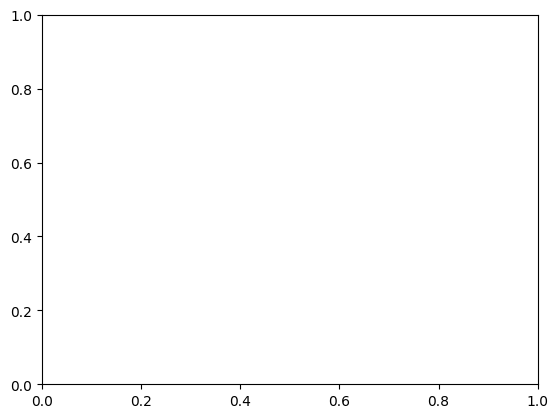

In [24]:
# Mass Combo plot
dim_n_obj_combs = [(2, 5), (3, 4), (4, 3), (5, 2)]
shift_dim = True
for solver in ["GDE3", "NSGAII", "IBEA", "MOEAD", "diverse_tree"]:
    for tree in ["breadth", "depth"]:
        filtered_dfs = []
        for dim_n_obj_comb in dim_n_obj_combs:
            dimension = dim_n_obj_comb[0]
            n_objectives = dim_n_obj_comb[1]
            filtered_dfs.append(
                new_df[
                    (new_df["solver"] == solver)
                    & (new_df["dimension"] == dimension)
                    & (new_df["tree"] == tree)
                    & (new_df["n_objectives"] == n_objectives)
                ]
            )
        filtered_df = pd.concat(filtered_dfs)
        if solver == "MOEAD":
            solver_name = "MOEA/D"
        elif solver == "NSGAII":
            solver_name = "NSGA-II"
        else:
            solver_name = solver

        fig, axs = plt.subplots(1, 4, figsize=(12, 3), dpi=600)
        fig.suptitle(
            f"Distribution of {solver_name}'s sampling points under {tree} tree $\operatorname{{dim}}X={dimension + n_objectives - 1}$",
            fontsize=18,
        )
        fig.tight_layout(pad=2, w_pad=4, h_pad=5)
        width = 0.6
        colors = ["#8fdea0", "#ec80b4", "#eed5a4", "#9a97dc", "#d7e7f5"]
        palette = sns.color_palette(colors)

        for n_objective, sub_df in filtered_df.groupby("n_objectives"):
            sub_results = []
            for sub_index, row in sub_df.iterrows():
                sub_results.append({"node_name": "root", "percentage": row["root"]})
                sub_results.append({"node_name": "1", "percentage": row["node_1"]})
                sub_results.append({"node_name": "2", "percentage": row["node_2"]})
                sub_results.append({"node_name": "3", "percentage": row["node_3"]})
                sub_results.append({"node_name": "4", "percentage": row["node_4"]})
            sub_results = pd.DataFrame(sub_results)
            plt.subplot(1, 4, n_objective - 1)
            plt.title(f"N objectives = {n_objective}", fontsize=16)
            # pt.RainCloud(x="day", y="total_bill", data=tips, orient="v")
            # axs[plot_row,plot_col].set_xlabel("Basin name")
            # axs[plot_row,plot_col].set_ylabel("Percentage of solver instances")
            # axs[plot_row,plot_col].set_ylim([-5, 105])

            plt.ylim([-5, 105])
            # plt.grid(visible=False)
            pt.RainCloud(
                data=sub_results,
                x="node_name",
                y="percentage",
                orient="v",
                width_viol=0.9,
                linewidth=0.1,
                point_size=3,
                rain_edgecolor="black",
                rain_linewidth=0.5,
                rain_alpha=1,
                move=0.15,
                width_box=0,
                box_linewidth=0,
                offset=-0.0,
                pointplot=True,
                point_linestyles="",
                point_scale=0.3,
                palette=palette,
            )
            plt.xlabel("Basin ID", fontsize=16)
            plt.ylabel("Percentage (%)", fontsize=16)
            plt.xticks(fontsize=14)
            plt.yticks(fontsize=14)
        plt.savefig(
            f"../utils/mass_combo/mass_{solver}_{tree}_comb-dim{dimension + n_objectives - 1}_{'_shifted' if shift_dim else ''}.pdf",
            format="pdf",
            bbox_inches="tight",
        )
        plt.savefig(
            f"../utils/mass_combo/mass_{solver}_{tree}_comb-dim{dimension + n_objectives - 1}_{'_shifted' if shift_dim else ''}.png"
        )
        plt.close("all")  # Closes all open figures
        plt.clf()  # Clears the current figure (if one exists)
        plt.cla()  # Clears the current axes (if any exist)